# Chargement des packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Chargement du dataset

In [2]:
df = pd.read_csv("../data/city_lifestyle_dataset.csv")

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    str    
 1   country                 300 non-null    str    
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), str(2)
memory usage: 23.6 KB
None


# Suprresion des colonees non numeric comme city_name et country

In [4]:
df_numeric = df.drop(columns=["city_name", "country"])

# Normalisation

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# TSNE

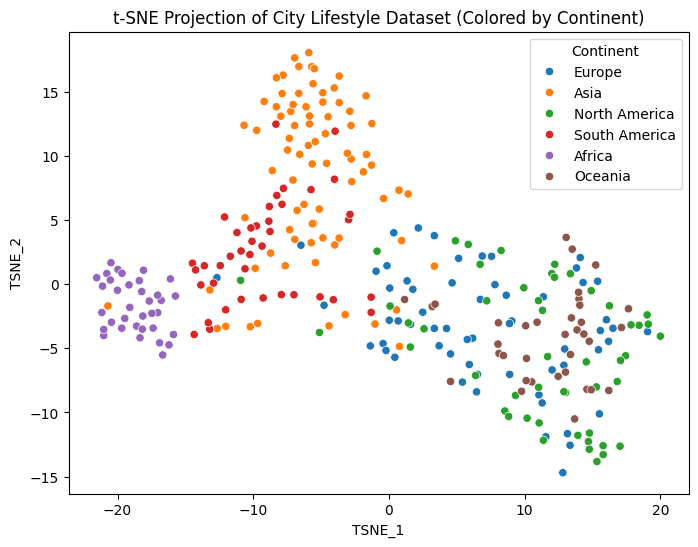

In [15]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    "TSNE_1": X_tsne[:, 0],
    "TSNE_2": X_tsne[:, 1]
})

tsne_df["Continent"] = df["country"]

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="TSNE_1",
    y="TSNE_2",
    hue="Continent",
    data=tsne_df,
    palette="tab10"
)

plt.title("t-SNE Projection of City Lifestyle Dataset (Colored by Continent)")
plt.show()

# Analyse

À gauche, le cluster **violet** (Afrique) est nettement isolé.
En haut, le groupe **orange** (Asie) apparaît dense et relativement compact.
À droite, les clusters **bleu** (Europe) et **vert** (Amérique du Nord) sont proches, suggérant des profils lifestyle similaires.
Le cluster **rouge** (Amérique du Sud) occupe une position intermédiaire, tandis que le **marron** (Océanie) se situe à droite, proche des régions développées.

La distribution spatiale et les couleurs montrent que les villes tendent à se regrouper par similarité socio-économique et géographique.

